Loading model and data...
Model has 56,324 parameters
Creating dataloaders from ../../data/raw/dynamics_data_0000.h5
  Batch size: 1
  Num workers: 0
  Split: 0.7/0.15/0.15000000000000005
Found 53 unique episodes
Split 53 episodes:
  Train: 37 (69.8%)
  Val: 7 (13.2%)
  Test: 9 (17.0%)

Creating datasets...
Creating chunk index for 37 episodes...
Created 8358 chunks (chunk_length=10)
Creating chunk index for 7 episodes...
Created 1557 chunks (chunk_length=10)
Creating chunk index for 9 episodes...
Created 1684 chunks (chunk_length=10)

Creating dataloaders...

DataLoaders created:
  Train: 8358 chunks → 8358 batches
  Val:   1557 chunks → 1557 batches
  Test:  1684 chunks → 1684 batches
Loaded batch with BEV map shape: torch.Size([1, 1, 26, 26])
Predictions generated!
  height: torch.Size([1, 26, 26])
  stiffness: torch.Size([1, 26, 26])
  damping: torch.Size([1, 26, 26])
  friction: torch.Size([1, 26, 26])


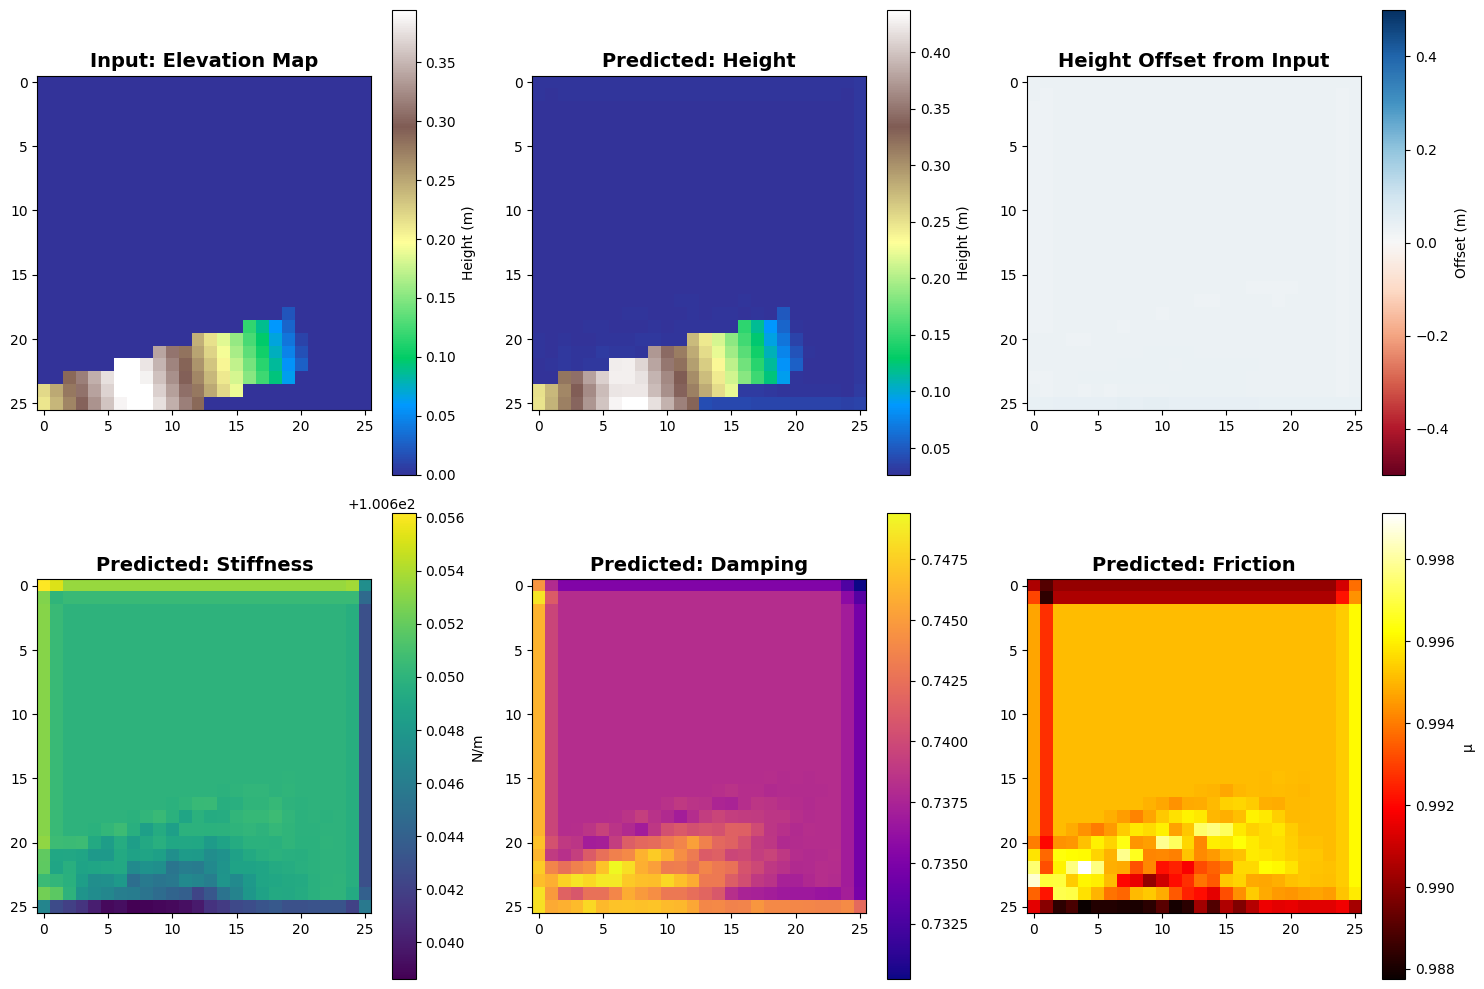


✓ Visualization saved as 'terrain_predictions.png'

PREDICTION STATISTICS

HEIGHT:
  Mean:      0.059
  Median:    0.059
  Std:       0.092
  Min:       0.026
  Max:       0.437

STIFFNESS:
  Mean:    100.649
  Median:  100.649
  Std:       0.002
  Min:     100.639
  Max:     100.656

DAMPING:
  Mean:      0.739
  Median:    0.739
  Std:       0.003
  Min:       0.730
  Max:       0.749

FRICTION:
  Mean:      0.994
  Median:    0.994
  Std:       0.002
  Min:       0.988
  Max:       0.999

TESTING ON MULTIPLE SAMPLES


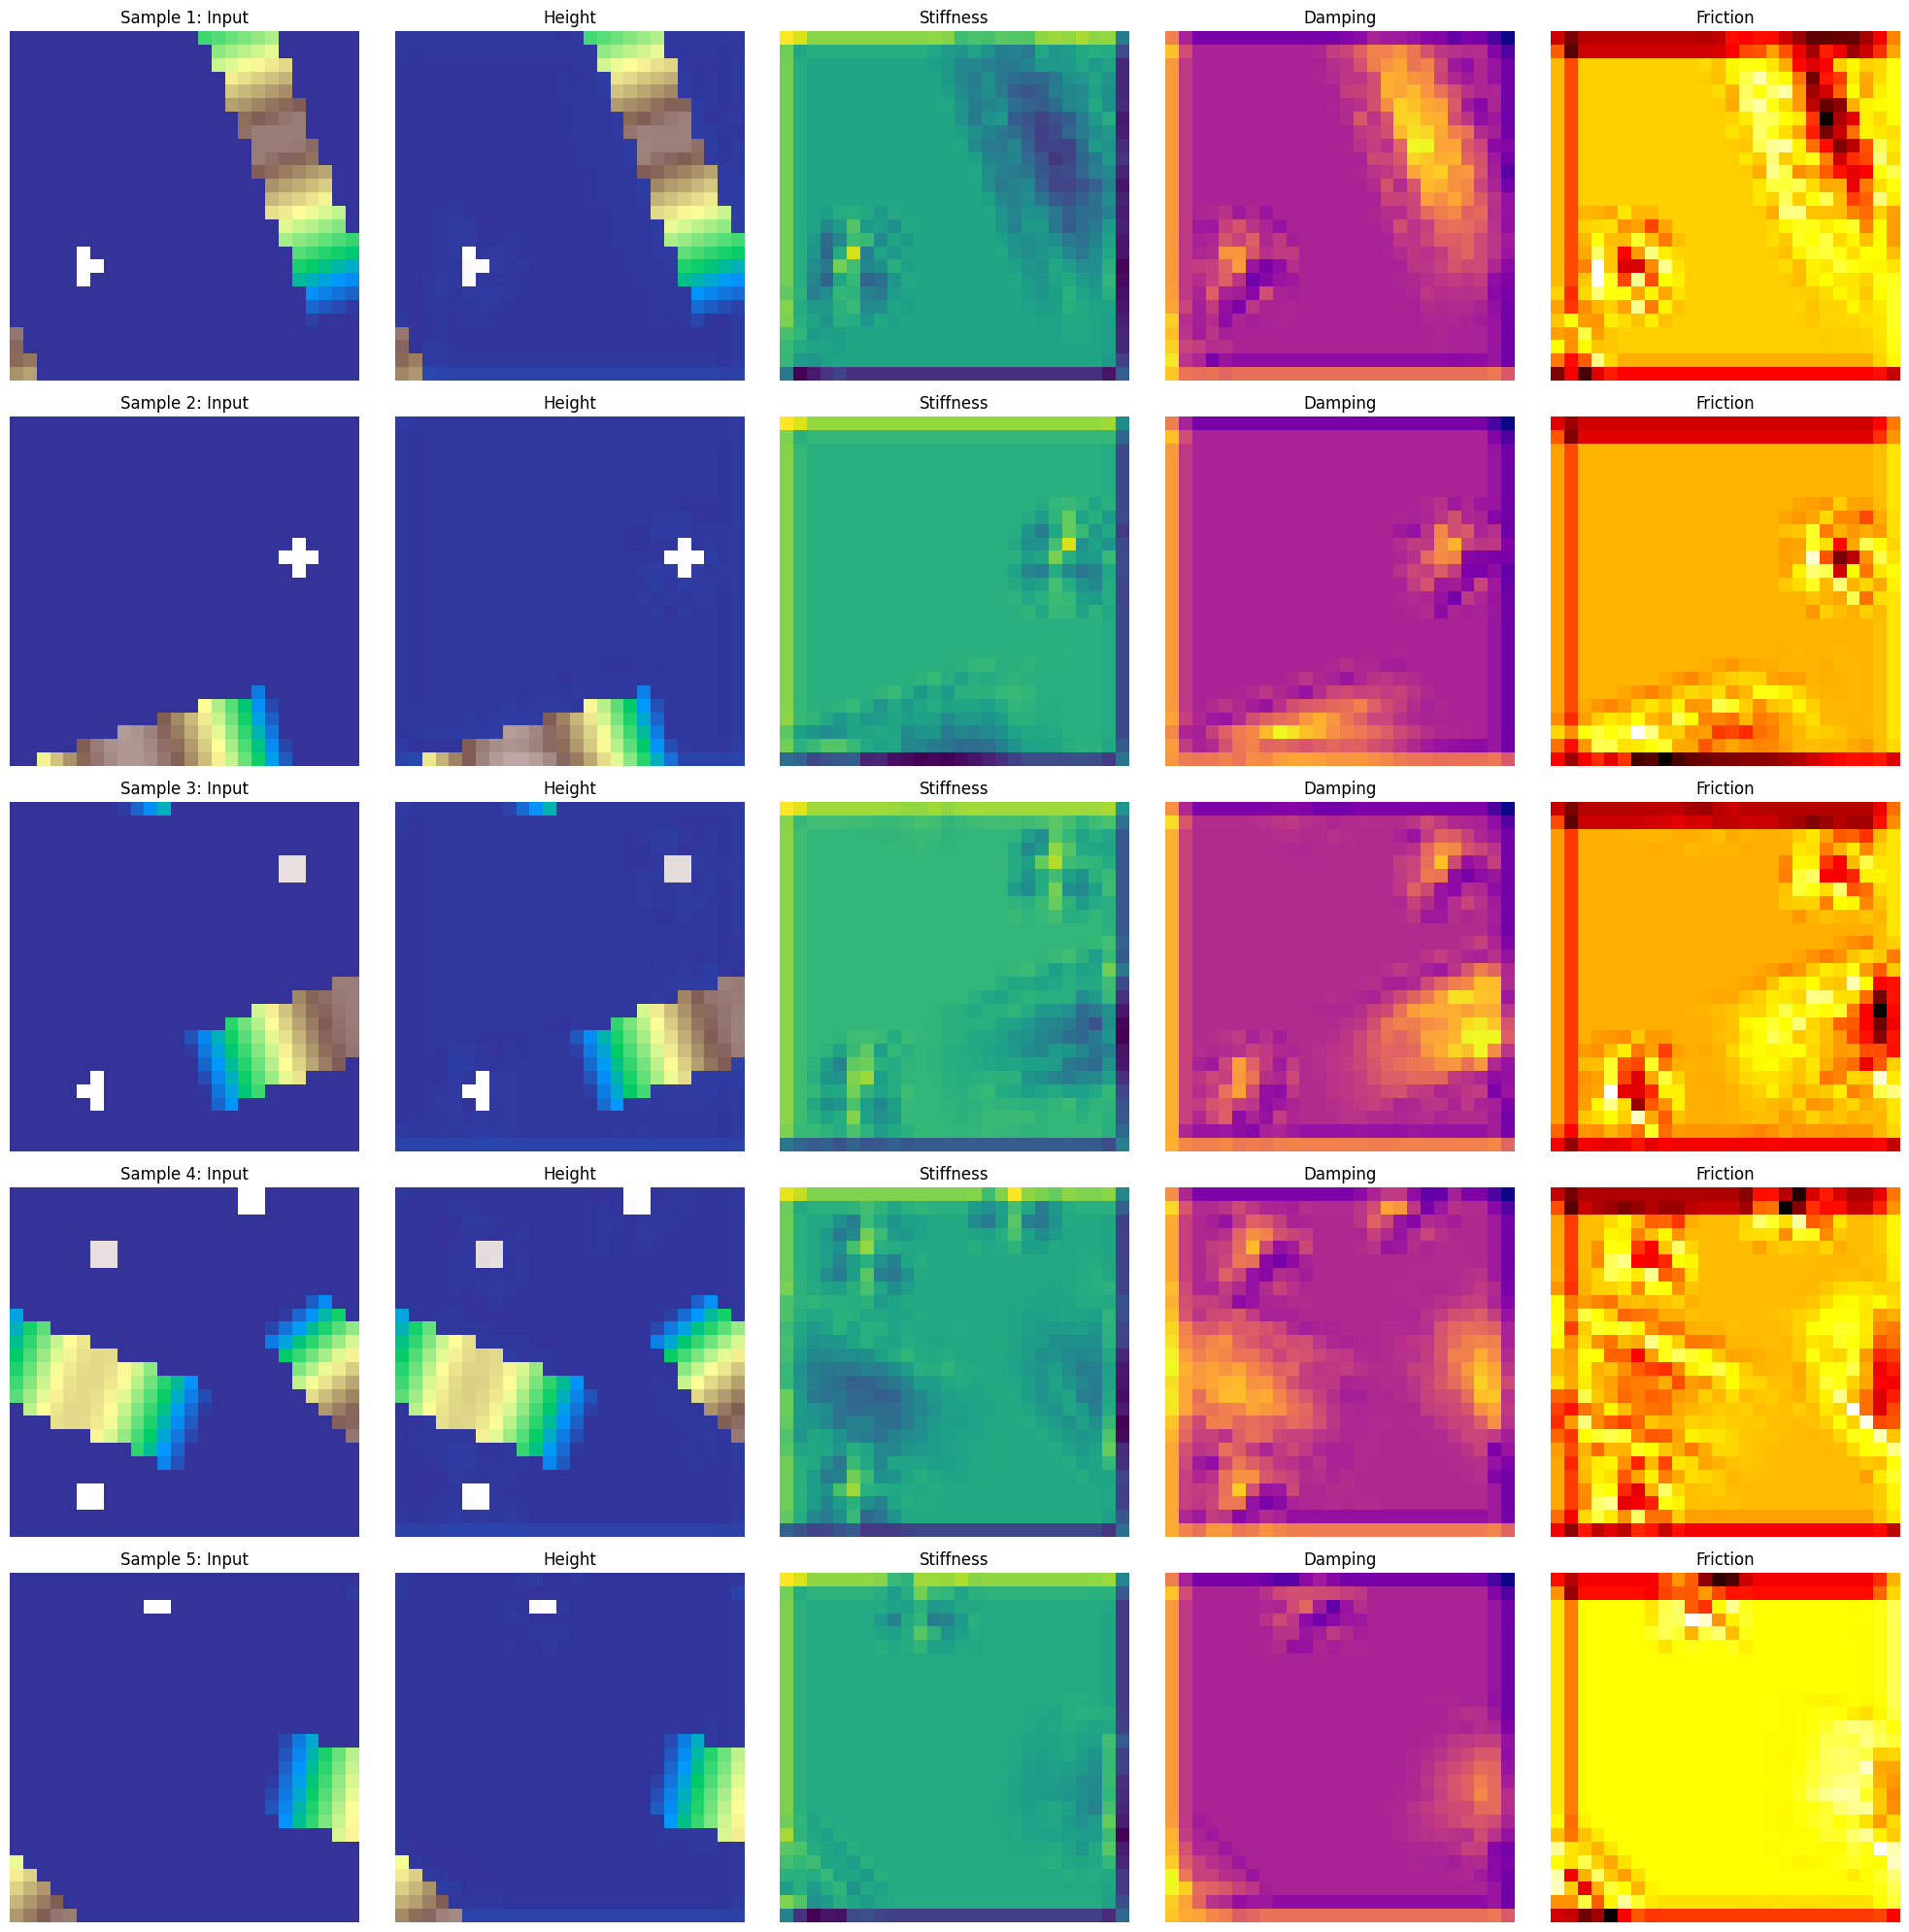

✓ Multiple sample visualization saved


In [2]:
# Cell 1: Setup
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from f1_vault.models import TerrainEncoder
from f1_vault.data import create_dataloaders

print("Loading model and data...")

# Cell 2: Load model
model = TerrainEncoder()
model.eval()

print(f"Model has {model.count_parameters():,} parameters")

# Cell 3: Load data
train_loader, _, _ = create_dataloaders(
    '../../data/raw/dynamics_data_0000.h5',
    batch_size=1,
    num_workers=0
)

batch = next(iter(train_loader))
print(f"Loaded batch with BEV map shape: {batch['bev_map'].shape}")

# Cell 4: Run model
with torch.no_grad():
    predictions = model(batch['bev_map'])

print("Predictions generated!")
for key, value in predictions.items():
    print(f"  {key}: {value.shape}")

# Cell 5: Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Input elevation map
im0 = axes[0, 0].imshow(batch['bev_map'][0, 0].cpu(), cmap='terrain')
axes[0, 0].set_title('Input: Elevation Map', fontsize=14, fontweight='bold')
plt.colorbar(im0, ax=axes[0, 0], label='Height (m)')

# Predicted height
im1 = axes[0, 1].imshow(predictions['height'][0].cpu(), cmap='terrain')
axes[0, 1].set_title('Predicted: Height', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], label='Height (m)')

# Height difference (residual)
height_diff = predictions['height'][0].cpu() - batch['bev_map'][0, 0].cpu()
im2 = axes[0, 2].imshow(height_diff, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[0, 2].set_title('Height Offset from Input', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 2], label='Offset (m)')

# Predicted stiffness
im3 = axes[1, 0].imshow(predictions['stiffness'][0].cpu(), cmap='viridis')
axes[1, 0].set_title('Predicted: Stiffness', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='N/m')

# Predicted damping
im4 = axes[1, 1].imshow(predictions['damping'][0].cpu(), cmap='plasma')
axes[1, 1].set_title('Predicted: Damping', fontsize=14, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1])

# Predicted friction
im5 = axes[1, 2].imshow(predictions['friction'][0].cpu(), cmap='hot')
axes[1, 2].set_title('Predicted: Friction', fontsize=14, fontweight='bold')
plt.colorbar(im5, ax=axes[1, 2], label='μ')

plt.tight_layout()
plt.savefig('terrain_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'terrain_predictions.png'")

# Cell 6: Statistics
print("\n" + "="*60)
print("PREDICTION STATISTICS")
print("="*60)

for key, tensor in predictions.items():
    values = tensor[0].cpu().numpy()
    print(f"\n{key.upper()}:")
    print(f"  Mean:   {values.mean():8.3f}")
    print(f"  Median: {values.mean():8.3f}")
    print(f"  Std:    {values.std():8.3f}")
    print(f"  Min:    {values.min():8.3f}")
    print(f"  Max:    {values.max():8.3f}")

# Cell 7: Test on multiple samples
print("\n" + "="*60)
print("TESTING ON MULTIPLE SAMPLES")
print("="*60)

n_samples = 5

fig, axes = plt.subplots(n_samples, 5, figsize=(20, 4*n_samples))

for i in range(n_samples):
    batch = next(iter(train_loader))
    
    with torch.no_grad():
        pred = model(batch['bev_map'])
    
    # Input
    axes[i, 0].imshow(batch['bev_map'][0, 0].cpu(), cmap='terrain')
    axes[i, 0].set_title(f'Sample {i+1}: Input')
    axes[i, 0].axis('off')
    
    # Height
    axes[i, 1].imshow(pred['height'][0].cpu(), cmap='terrain')
    axes[i, 1].set_title('Height')
    axes[i, 1].axis('off')
    
    # Stiffness
    axes[i, 2].imshow(pred['stiffness'][0].cpu(), cmap='viridis')
    axes[i, 2].set_title('Stiffness')
    axes[i, 2].axis('off')
    
    # Damping
    axes[i, 3].imshow(pred['damping'][0].cpu(), cmap='plasma')
    axes[i, 3].set_title('Damping')
    axes[i, 3].axis('off')
    
    # Friction
    axes[i, 4].imshow(pred['friction'][0].cpu(), cmap='hot')
    axes[i, 4].set_title('Friction')
    axes[i, 4].axis('off')

plt.tight_layout()
plt.savefig('multiple_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Multiple sample visualization saved")